# Семинар 6 (20.11.2025). Молекулярная динамика 1: белок в воде

# 1. Теоретические основы метода молекулярной динамики (МД)

## 1.1. Место МД в мире моделирования

<img src="IMAGES/MD_place.png" alt="drawing" style="width:1000px;"/> 

Молекулярное моделирование биомолекул возможно на различных пространственно-временных масштабах:

* **Квантово-химические методы (*ab initio*)**: 
  * для малых систем (до $~10^2$ атомов)
  * решение уравнения Шредингера с определенным уровнем точности
  * дают наиболее точное описание системы, но сильно ограничены размером и временем моделирования

* Для макромолекул чаще всего применяется **метод молекулярной динамики (МД)**
  * переход на уровень классической механики
  * атомы представляются как шарики, соединённые пружинками
  * движение определяется численным интегрированием уравнений Ньютона

* **Крупнозернистые методы**: 
  * моделирование на уровне групп - объединенных атомов/остатков
  * подходит для крупных биосистем и даже клеток

Сегодня мы фокусируемся на МД. Где она применяется? 
* для уточнения экспериментальных структур (например, когда непонятно, что из себя представляет наблюдаемая крио-ЭМ плотность)
* для исследования конформаций биомолекул и переходов между ними (другими словами, их "жизни")
* при изучении взаимодействия белков с их лигандами, транспорта ионов через мембрану и т.д.

Также есть расширенные методы МД, позволяющие расчитывать свободную энергию (методы возмущения свободной энергии, метадинамики и тд.). Они применяются, в частности, в пайплайнах фармацевтических компаний при отборе потенциальных лекарственных молекул. 


> Дополнительно:
> * https://www.drugdesign.org/chapters/molecular-dynamics/ 
> * https://computecanada.github.io/molmodsim-md-theory-lesson-novice/aio/index.html

## 1.2. Немного истории

<img src="IMAGES/historical.png" alt="drawing" style="width:600px;"/>


История методов МД включает несколько ключевых этапов. 
* В 1950–1960-х годах появились первые численные методы моделирования - работы Метрополиса (1953), модель твёрдых сфер Альдера и Уэйнрайта (1957)
* в 1964 году Рахман впервые применил молекулярную динамику для моделирования жидкости (аргона). 
* В 1970-1980-х годах были разработаны важные алгоритмы интегрирования (алгоритм Верле, 1967), создано программное обеспечение (например, CHARMM, AMBER) и началось активное применение МД к биомолекулярным системам.​
* С 1990-х годов и по настоящее время молекулярная динамика интенсивно развивается благодаря росту вычислительных мощностей (GPU, суперкомпьютеры ANTON), улучшению силовых полей, развитию новых методов (т.н. "улучшенного сэмплирования") для более быстрого получения всего конформационного пространства системы, а также гибридных подходов (квантово-механические и машинное обучение). 

Таким образом, к настоящему времени МД стала незаменимым инструментом в биофизике, структурной биологии и фармацевтике.​

<img src="IMAGES/historical.webp" alt="drawing" style="width:600px;"/> 

*Историческая шкала развития моделирования молекулярной динамики биологических систем https://doi.org/10.1007/978-1-0716-1394-8_18*


<img src="IMAGES/MD_number.png" alt="drawing" style="width:500px;"/> 

*Количество статей по МД в год с 1975 года https://doi.org/10.1038/srep26536*

> Дополнительно: 
> * https://biomolecula.ru/articles/molekuliarnaia-dinamika-biomolekul-chast-i-istoriia-poluvekovoi-davnosti
> * https://biomolecula.ru/articles/millisekundnyi-barer-vziat
> * https://biomolecula.ru/articles/kalievyi-kanal-in-silico
> * Реферат по истории методов МД `Materials/Реферат_ИФН_31-03-2025.pdf`

## 1.3. Алгоритм МД 

#### Общая концепция


* Изначально мы знаем положение всех атомов в системе (например, из экспериментальной структуры)
* Генерируем скорости при заданной температуре (из распределения Максвелла)
* Далее в цикле: 
  * рассчитываем силы, действующие на каждый атом
  * пишем второй закон Ньютона
  * интегрируем с фиксированным шагом dt
  * получаем новые координаты и скорости - следующий фрейм
* Продолжаем этот цикл, пока не наберется нужная нам длина траектории. 


<img src="IMAGES/MD_algo2.png" alt="drawing" style="width:700px;"/> 

*Алгоритм молекулярной динамики https://www.researchgate.net/publication/224370553_Influence_of_molecular_models_of_water_on_computer_simulations_of_water_nanoflows*

### Силовые поля

Как же рассчитываются силы, действующие на каждый атом? Из потенциальной энергии, которая определяется с помощью силового поля. 

**Силовое поле (СП)** – модель и набор параметров для теоретического описания межатомных взаимодействий. Оно применяется для быстрой оценки энергии взаимодействия, в частности, в методах молекулярной механики, молекулярной динамики и докинга.

<img src="IMAGES/FF_eq.png" alt="drawing" style="width:600px;"/> 

*Описание потенциальной энергии молекулярной системы в силовом поле https://biomolecula.ru/articles/molekuliarnaia-dinamika-biomolekul-chast-i-istoriia-poluvekovoi-davnosti* 

Все взаимодействия в МД делятся на связанные и несвязанные. 
* Связанные взаимодействия включают в себя: 
  * энергию ковалентных связей
  * энергию валентных углов
  * энергию двугранных углов
* Несвязанные взаимодействия - силы Ван-дер-Ваальса (потенциал Леннарда-Джонса) и электростатические взаимодействия (потенциал Кулона)

Параметры для расчета взаимодействий определяются в каждом СП по-разному: эмпирически и/или из квантово-механических расчетов. 

Наиболее известными полноатомными силовыми полями для белков и липидов являются:
* AMBER - Assisted Model Building and Energy Refinement
* CHARMM - Chemistry at HARvard Macromolecular Mechanics
* OPLS (Optimized Potential for Liquid Simulations) - параметры для изучения жидкостей, фазовых переходов и т.д
* GROMOS - силовое поле объединенных атомов без алифатических водородов


<img src="IMAGES/MD_FF.png" alt="drawing" style="width:1000px;"/> 

*https://doi.org/10.1002/wcms.1358*

> Почитать:
> * https://biomolecula.ru/articles/molekuliarnaia-dinamika-biomolekul-chast-i-istoriia-poluvekovoi-davnosti

## Достоинства и недостатки МД

<img src="IMAGES/MD_pm.png" alt="drawing" style="width:800px;"/> 

Вывод: **МД - мощный инструмент, но использоваь его надо аккуратно и с пониманием его границ применимости**


# 2. Практические основы МД

## 2.1. Пайплайн моделирования

Пайплайн МД состоит из следующих этапов: 
1. Сначала выбирается модельная система, в которой фиксируются недостающие сегменты, определяются состояние протонирования, частичные заряды, добавляется растворитель (вода/ионы/мембрана). 
2. Затем система минимизируется по энергии и уравновешивается путём решения уравнений движения Ньютона до тех пор, пока её свойства не перестанут меняться со временем. 
3. После достижения равновесия выполняется production run в течение требуемого периода времени для получения траекторий
4. Полученные траектории анализируют на предмет интересующих свойств

<img src="IMAGES/Molecular-Dynamics-Simulation-1.png" alt="drawing" style="width:1000px;"/> 

*Стандартный пайплайн молекулярной динамики https://www.profacgen.com/molecular-dynamics-simulation.htm*

## 2.2. Софт для МД

Наиболее часто используемые программы для МД-расчётов: **GROMACS, CHARMM, AMBER, NAMD и LAMMPS**. Все эти программы обладают как общими функциями, так и уникальными возможностями. Некоторые из них имеют открытый исходный код (например, GROMACS и LAMMPS), другие являются коммерческими. Для биологических приложений чаще всего использут GROMACS. Для других приложений, например, для материалов и жидкостей, LAMMPS — отличный инструмент.

<img src="IMAGES/MD_soft.png" alt="drawing" style="width:1000px;"/> 

*https://doi.org/10.1002/wcms.1358*

<img src="IMAGES/MD_engine.png" alt="drawing" style="width:500px;"/> 


*Количество цитирований (Google Scholar) основных публикаций наиболее используемых инструментов МД в год. VMD - популярная программа для настройки и анализа результатов МД. https://doi.org/10.1038/srep26536*

> Дополнительно: 
> * https://www.scijournal.org/articles/best-software-for-molecular-modeling-and-simulations
> * https://www.rcsb.org/docs/additional-resources/modeling-and-simulation-software
> * https://en.wikipedia.org/wiki/Comparison_of_software_for_molecular_mechanics_modeling

## 2.3. О высокопроизводительных вычислениях в МД

Высокопроизводительные вычисления (HPC) играют важную роль в современной МД, поскольку моделирование сложных биомолекулярных систем требует значительных вычислительных ресурсов из-за огромного числа параллельно выполняемых вычислений (например, расчет сил для миллионов атомов на каждом шаге). Для подобных расчётов недостаточно возможностей обычных компьютеров. Использование HPC позволяет проводить длительные и масштабные симуляции, которые ранее были невозможны, а также значительно сокращает время получения результатов.

Современные суперкомпьютеры и кластеры используют не только многоядерные CPU, но и вычислительные графические процессоры (GPU), что позволяет реализовать массовый параллелизм и существенно ускорить моделирование. Использование GPU стало ключевым для эффективной работы МД-пакетов (например, GROMACS): при том же бюджете возможно получить производительность, сравнимую с крупными кластерами CPU, а энергозатраты и стоимость оборудования заметно ниже. 

* GPU-ускорение в GROMACS позволяет в 5–10 раз увеличить производительность, ускоряя расчет не только короткодействующих, но и длиннодействующих взаимодействий (например, PME);​

* Для большинства задач МД уже одной современной видеокарты достаточно, чтобы достичь производительности большого CPU-кластера, а стоимость и энергопотребление при этом существенно ниже.​

Таким образом, использование GPU стало стандартом для современных МД-симуляций, открывая возможности моделировать крупные биомолекулы и выполнять протяжённые по времени расчёты, которые ранее были невозможны на CPU.​

<img src="IMAGES/CPU-GPU.webp" alt="drawing" style="width:300px"/> 

*https://www.mpinat.mpg.de/grubmueller/gromacs*

> Дополнительно: 
> * https://hpc.fau.de/2022/02/10/gromacs-performance-on-different-gpu-types/
> * https://manual.gromacs.org/current/user-guide/mdrun-performance.html

# 3. Практика: лизоцим в воде (GROMACS)


**Задача: провести МД-моделирование водорастворимого белка (лизоцима) в воде с ионами в программном пакете GROMACS**

<img src="IMAGES/Gmx_logo_blue.png" alt="drawing" style="width:300px"/> 

<img src="IMAGES/Lysozyme.png" alt="drawing" style="width:300px"/>  

## 3.1. Подключение к серверу

### 3.1.1. SSH

```bash
ssh -p 17222 student@nmr63.nmr.ru
пароль: *** #будет в чате курса в Telegram
ssh go
mkdir SURNAME
cd SURNAME
```

SSH клиент должен быть по-умолчанию в терминале Linux/MacOS и Windows (https://learn.microsoft.com/ru-ru/windows/terminal/tutorials/ssh). Если у вас это не так, то сообщите об этом, разберемся.

**Важно: каждый студент создает свою папку и работает в ней!**

### 3.1.2. SFTP

Для просмотра и передачи файлов на сервер удобно использовать SFTP-клиенты. 
* WinSCP (Windows) - https://winscp.net/eng/download.php
* FileZilla (Windows/MacOS/Linux) - https://filezilla-project.org/download.php?type=client
* встроенный в файловый менеджер SFTP-клиент (точно есть в Linux, возможно, и в MacOS) 

**Подключение к сереверу через FileZilla**

`File -> Site Manager`


<img src="IMAGES/SFTP-1.png" alt="drawing" style="width:600px"/> 

<img src="IMAGES/SFTP-2.png" alt="drawing" style="width:800px"/> 


**Аналогично - через Nemo (файловый менеджер Ubuntu)**

`File -> Connect to server`

<img src="IMAGES/SFTP-3.png" alt="drawing" style="width:800px"/> 

Ура, у нас есть доступ к серверу. Самое время начать моделировать!

### 3.1.3. Проверка загрузки вычислительного узла

Перед тем, как начать работать на вычислительном узле, полезно оценить, свободен ли он (особенно при запуске МД командой `gmx mdrun`). 

**`nvidia-smi`** 
* предназначена для мониторинга и управления видеокартами NVIDIA. 
* позволяет отслеживать рабочую нагрузку, температуру, энергопотребление и другие параметры GPU, а также управлять некоторыми настройками. 

Свободная GPU

<img src="IMAGES/gpu_0.png" alt="drawing" style="width:600px"/> 

Загруженная GPU

<img src="IMAGES/gpu_100.png" alt="drawing" style="width:600px"/> 

**`htop`**

* показывает общее количество процессов и сколько из них активны

Свободные CPU

<img src="IMAGES/htop_0.png" alt="drawing" style="width:600px"/> 

Загруженные CPU

<img src="IMAGES/htop_100.png" alt="drawing" style="width:600px"/> 

> **Важно: не надо запускать расчет МД на загруженном узле, подождите, пока он освободится (и напишите в чат курса, если этого долго не происходит)**

### 3.1.4. Папка с примером МД из этого семинара

На кластере `/home/veretenenko/MolMod-2025/lysozyme`

## 3.2. Модельный белок

**Лизоцим** — это фермент, который обладает противомикробной активностью, разрушая клеточные стенки бактерий путем гидролиза пептидогликана (муреина).

**Свойства и функции**
* Антимикробная активность: разрушает клеточные стенки бактерий - особенно эффективно против грамположительных микроорганизмов 
* Часть иммунной системы: является естественной защитой организма, входит в состав слез, слюны и других биологических жидкостей 
* Противовирусное действие: может инактивировать некоторые вирусы, связываясь с их белками и нуклеиновыми кислотами

**Применение**
* Пищевая промышленность: используется в качестве консерванта, например, при производстве сыров, пива и вина для предотвращения роста нежелательных бактерий
* Медицина: применяется для лечения инфекционно-воспалительных заболеваний, таких как пневмония, стоматит и гингивит, а также в стоматологии
* Биотехнология: используется в лабораторных условиях для разрушения клеток при экстракции белков и нуклеиновых кислот

**Источники**
* Куриные яйца: являются основным источником для промышленного получения фермента
* Другие источники: в небольших количествах содержится в других животных тканях, растениях, а также выделяется человеческим организмом


<img src="IMAGES/molecules-29-00652-g001.png" alt="drawing" style="width:600px"/> 


Ссылка на структуру: https://www.rcsb.org/structure/1AKI

Скачиваем файл и загружаем его в свою папку: либо через SFTP, либо в командной строке `scp -r -P 17222 1aki.pdb  student@nmr63.nmr.ru:~/SURNAME`

## 3.3. Пайплайн подготовки и запуска МД в GROMACS

<img src="IMAGES/flow.png" alt="drawing" style="width:600px"/> 

*Общая схема подготовки и расчета МД https://www3.mpibpc.mpg.de/groups/de_groot/compbio1/p2/*

Настраиваем переменную окружения для запуска GROMACS (команда `gmx`)


```bash
source /usr/local/gromacs-2024.4/bin/GMXRC
gmx --version #проверка, что все работает
```


## 3.4. Подготовка структуры

В экспериментально полученных структурах pdb могут присутствовать не принадлежащие белку атомы, например лиганды и вода. Если они присутствуют, необходимо удалить их из структуры.


```bash
grep -v HOH 1AKI.pdb > 1AKI_clean.pdb
```

## 3.5. Генерация файла топологии

C помощью pdb2gmx создается файл топологии (`topol.top`) системы, включающий в себя всю информацию, необходимую для моделирования (типы атомов, заряды, связи, углы, двугранные углы и т.д.)

Для создания топологии необходимо задать силовое поле. В GROMACS встроены наиболее популярные GROMOS, AMBER, CHARMM, OPLS-AA.
 
<img src="IMAGES/ff_table.png" alt="drawing" style="width:400px"/> 

*https://doi.org/10.1021/ct300102d*

В данном случае было выбрано полноатомное силовое поле [CHARMM36](http://mackerell.umaryland.edu/charmm_ff.shtml#gromacs) (доработанная версия CHARMM27), предназначенное для белков, липидов и нуклеиновых кислот.

CHARMM36 необходимо скачать и разархивировать в рабочую директорию

```bash
wget -c "http://mackerell.umaryland.edu/download.php?filename=CHARMM_ff_params_files/charmm36-jul2022.ff.tgz" -O charmm36-jul2022.ff.tgz
tar -zxvf charmm36-jul2022.ff.tgz
```

Помимо выбора силового поля необходимо выбрать модель воды. Для CHARMM используется трехточечная модель TIP3P.

Генерируем файл топологии (выбираем `1: CHARMM all-atom force field`):


```bash
gmx pdb2gmx -f 1AKI_clean.pdb -o 1AKI_processed.gro -water tip3p
```

**Файлы на выходе:**


1. `topol.top` — топология молекулы (содержит все параметры силового поля, необходимые для моделирования)
2. `posre.itp` — файл ограничений
3. `1AKI_processed.gro` — обработанная структура
   


## 3.6. Определение элементарной ячейки, добавление растворителя и ионов


Молекулярная динамика обычно проводится в периодических граничных условиях. Поэтому в данном разделе определяется элементарная ячейчка, в которой находится белок. Далее она заполняется растворителем (водой с ионами). 

<img src="IMAGES/MD_pbc.png" alt="drawing" style="width:500px"/>
 
*https://doi.org/10.1002/wcms.1563*

### 3.6.1. Создание элементарной ячейки

Для создания элементарной ячейки используется editconf с параметрами: 
* `-с` - центрирование белка в ячейке
* `-d 1.0` - помещает белок на расстоянии не менее 1 нм от границы ячейки. Это нужно для того, чтобы белок не видел свой периодический образ (при расстоянии до границы 1 нм расстояния между периодическими образами белка составляют не менее 2 нм)
* `-bt cubic` - форма элементарной ячейки

```bash
gmx editconf -f 1AKI_processed.gro -o 1AKI_newbox.gro -c -d 1.0 -bt cubic
```

<img src="IMAGES/MD1.png" alt="drawing" style="width:700px"/> 

### 3.6.2. Сольватация белка


Добавление растворителя производится с помощью `solvate` с spc216.gro - общей уравновешенной трехточечной модели растворителя, используемой для трехточечных моделей воды, в том числе TIP3P:


```bash
gmx solvate -cp 1AKI_newbox.gro -cs spc216.gro -o 1AKI_solv.gro -p topol.top
```


Комментарий: в `topol.top` добавляется информация о количестве молекул воды.

```plain
[ molecules ]
; Compound        #mols
Protein_chain_A     1
SOL              7339

```

### 3.6.3. Добавление ионов

В выводе  gmx pdb2gmx можно найти сточку: 

```plain
Total mass 14313.255 a.m.u.
Total charge 8.000 e
```

Это означает, что белок заряженный (это также можно понять по последнему упоминанию `qtot 8` в разделе [atoms] файла `topol.top`). 

Так как система должна быть электронейтральной, необходимо добавить в нее ионы, компенсирующие заряд белка. Для этого используется `gmx genion`, который заменяет часть молекул воды ионами. 

**Подготовка файлов для genion**

`genion` принимает на вход файлы в формате .tpr (содержит все параметры для всех атомов в системе). Этот файл создается с помощью препроцессора gromacs `grompp`. Для него придется создать дополнительный файл `ions.mdp`

```plain

; ions.mdp - used as input into grompp to generate ions.tpr
; Parameters describing what to do, when to stop and what to save
integrator  = steep         ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0        ; Stop minimization when the maximum force  1000.0 kJmolnm
emstep      = 0.01          ; Minimization step size
nsteps      = 50000         ; Maximum number of (minimization) steps to perform

; Parameters describing how to find the neighbors of each atom and how to calculate the interactions
nstlist         = 1         ; Frequency to update the neighbor list and long range forces
cutoff-scheme	= Verlet    ; Buffered neighbor searching 
ns_type         = grid      ; Method to determine neighbor list (simple, grid)
coulombtype     = cutoff    ; Treatment of long range electrostatic interactions
rcoulomb        = 1.0       ; Short-range electrostatic cut-off
rvdw            = 1.0       ; Short-range Van der Waals cut-off
pbc             = xyz       ; Periodic Boundary Conditions in all 3 dimensions

```

```bash 
gmx grompp -f mdp/ions.mdp -c 1AKI_solv.gro -p topol.top -o ions.tpr
```

Заменяем воду на ионы NaCl и нейтрализуем систему. GROMACS предлагает выбрать, что можно заменить ионами. Выбираем `SOL` (т.к. не хотим заменять части белка ионами).


```bash
gmx genion -s ions.tpr -o 1AKI_solv_ions.gro -p topol.top -pname NA -nname CL -neutral
```


Ура, теперь в системе есть вода и ионы, что имитирует физиологическую среду!

<img src="IMAGES/MD2.png" alt="drawing" style="width:700px"/> 

## 3.7. Минимизация энергии

### 3.7.1. Подготовка файлов

После сборки надо релаксировать систему, чтобы в ней не было каких-либо стерических коллизий или неправильной геометрии.

Файл параметров моделирования `em.mdp` определяет, как должна выполняться минимизация. В данном случае используется файл для силового поля CHARMM, скачанный с официального туториала  Gromacs

```plain
; minim.mdp - used as input into grompp to generate em.tpr
; Parameters describing what to do, when to stop and what to save
integrator  = steep         ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0        ; Stop minimization when the maximum force < 1000.0 kJ/mol/nm
emstep      = 0.01          ; Minimization step size
nsteps      = 50000         ; Maximum number of (minimization) steps to perform

; Parameters describing how to find the neighbors of each atom and how to calculate the interactions
nstlist         = 1         ; Frequency to update the neighbor list and long range forces
cutoff-scheme   = Verlet    ; Buffered neighbor searching
ns_type         = grid      ; Method to determine neighbor list (simple, grid)
coulombtype     = PME       ; Treatment of long range electrostatic interactions
rcoulomb        = 1.0       ; Short-range electrostatic cut-off
rvdw            = 1.0       ; Short-range Van der Waals cut-off
pbc             = xyz       ; Periodic Boundary Conditions in all 3 dimensions

```

Создадим бинарный файл `em.tpr` с помощью `grompp`

```bash
gmx grompp -f mdp/em.mdp -c 1AKI_solv_ions.gro -p topol.top -o em.tpr
```

### 3.7.2. Запуск минимизации энергии

```bash 
nohup gmx mdrun -v -deffnm em -gpu_id 0 -nt 10 > em.job &
```

* `-gpu_id` - номер GPU, на котором надо выполнять расчет (см. `nvidia-smi`)
* `-nt` - число ядер (CPU), используемых для расчета (см. `htop`)
* `nohup` - команда, которая переводит другую команду (в данном случае, gmx mdrun) в бэкграунд (и она продолжит выполняться после закрытия терминала или разрыва сессии SSH). При этом все логи будут записаны в `em.job`

На выходе получили следующие файлы: 

* em.log: журнал процесса минимизации энергии (ASCII)
* em.edr: Файл энергии (binary)
* em.trr: Траектория (binary)
* em.gro: структура с минимизированной энегрией


### 3.7.3. Анализ процесса минимизации энергии

Факторы успешности процесса минимизации энергии: 
* Потенциальная энергия системы $E_{pot}$ в конце должна быть отрицательной и $\approx -10^5 кДж/моль$

* Максимальная сила $F_{max}$(целевое значение было задано в файле `em.mdp: emtol=1000.0`) должна быть меньше etmol, иначе система может быть недостаточно стабильной для моделирования.

В данном случае (вывод gmx mdrun): 

```plain
Steepest Descents converged to Fmax < 1000 in 248 steps
Potential Energy  = -5.1121631e+05
Maximum force     =  8.2413971e+02 on atom 1366
Norm of force     =  4.1361670e+01
```

Т.е. $E_{pot}\approx -5\cdot 10^{5} kJ/mol$, $F_{max} < 1000 kJ /(mol \cdot nm)$

Значит, минимизация энергии прошла успешно.

Построим также график потенциальной энергии системы от времени моделирования. Данные графика можно извлечь из файла em.edr

```bash
gmx energy -f em.edr -o potential.xvg
```


Выбираем опцию `11 Potential`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

,time,energy
0,0.0,-294309.59375
1,1.0,-310944.59375
2,2.0,-333477.84375
3,3.0,-361243.12500
4,4.0,-388665.28125
...,...,...
191,242.0,-510872.78125
192,243.0,-510940.34375
193,244.0,-510977.96875
194,245.0,-511026.15625


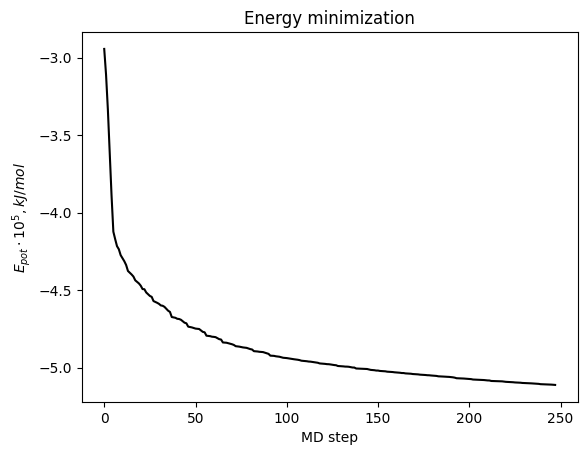

In [2]:
df = pd.read_csv('DATA/potential.xvg', header=None, names=['time','energy'], sep='\s+', skiprows = 24)
display(df)
plt.plot(df.time, df.energy/1e5, color = 'k')
plt.xlabel('MD step')
plt.ylabel('$E_{pot} \cdot 10^{5},  kJ / mol$')
plt.title('Energy minimization')
plt.show()

Видно, что энергия системы действительно минимизировалась.

## 3.8. Уравновешивание системы

На данном шаге структура уравновешена с точки зрения геометрии и ориентации растворителя.Теперь необходимо уравновесить растворитель и ионы вокруг белка (т.к. растворитель большей частью оптимизируется внутри себя, а не обязательно с растворенным веществом, и ионы размещаются случайным образом, замещая молекулы воды). 

Для оптимизации ориентации растворителя используется файл `posre.itp`, который определяет силовую постоянную, используемую для удержания атомов на месте во время уравновешивания. Он был сгенерирован pdb2gmx в разделе 2.2 при создании топологии системы. Для его использования в файл параметров моделирования будет добавлена строка `define = -DPOSRES`

### 3.8.1. NVT ансамбль (уравновешивание по объему)

В данном разделе производится уравновешивание при постоянном количестве частиц, объеме и температуре. Согласно документации, для этого достаточно 100-200 пс. 

Целевая температура системы задана 300 К

Файл `nvt.mdp`

```plain
title                   = OPLS Lysozyme NVT equilibration 
define                  = -DPOSRES  ; position restrain the protein
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 50000     ; 2 * 50000 = 100 ps
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 500       ; save coordinates every 1.0 ps
nstvout                 = 500       ; save velocities every 1.0 ps
nstenergy               = 500       ; save energies every 1.0 ps
nstlog                  = 500       ; update log file every 1.0 ps
; Bond parameters
continuation            = no        ; first dynamics run
constraint_algorithm    = lincs     ; holonomic constraints 
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Nonbonded settings 
cutoff-scheme           = Verlet    ; Buffered neighbor searching
ns_type                 = grid      ; search neighboring grid cells
nstlist                 = 10        ; 20 fs, largely irrelevant with Verlet
rcoulomb                = 1.0       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.0       ; short-range van der Waals cutoff (in nm)
DispCorr                = EnerPres  ; account for cut-off vdW scheme
; Electrostatics
coulombtype             = PME       ; Particle Mesh Ewald for long-range electrostatics
pme_order               = 4         ; cubic interpolation
fourierspacing          = 0.16      ; grid spacing for FFT
; Temperature coupling is on
tcoupl                  = V-rescale             ; modified Berendsen thermostat
tc-grps                 = Protein Non-Protein   ; two coupling groups - more accurate
tau_t                   = 0.1     0.1           ; time constant, in ps
ref_t                   = 300     300           ; reference temperature, one for each group, in K
; Pressure coupling is off
pcoupl                  = no        ; no pressure coupling in NVT
; Periodic boundary conditions
pbc                     = xyz       ; 3-D PBC
; Velocity generation
gen_vel                 = yes       ; assign velocities from Maxwell distribution
gen_temp                = 300       ; temperature for Maxwell distribution
gen_seed                = -1        ; generate a random seed
```

Генерируем tpr и запускаем heat

```bash
gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr
nohup gmx mdrun -v -deffnm nvt -gpu_id 0 -nt 10 -pin on -pinoffset 0 -pinstride 1 > nvt.job &
```

**График изменения температуры системы**

Посмотрим на график изменения температуры системы (выбираем `17 Temperature`): 

```bash
gmx energy -f nvt.edr -o temperature.xvg
```

,time,temperature
0,0.0,298.910583
1,1.0,298.643494
2,2.0,300.587372
3,3.0,299.091553
4,4.0,298.697845
...,...,...
96,96.0,300.646606
97,97.0,297.308075
98,98.0,295.991791
99,99.0,298.754578


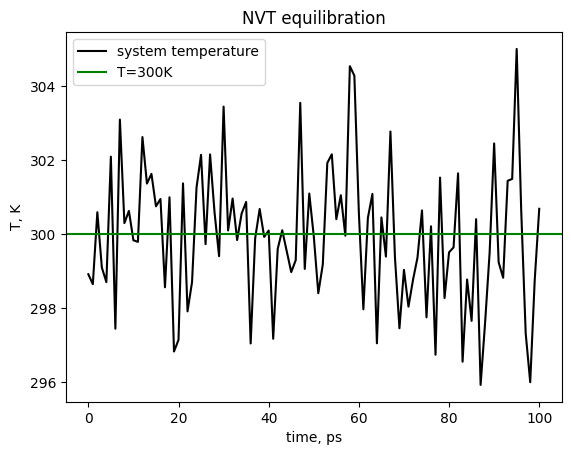

In [3]:
df = pd.read_csv('DATA/temperature.xvg', header=None, names=['time','temperature'], sep='\s+', skiprows = 24)
display(df)
plt.plot(df.time, df.temperature, color = 'k', label = 'system temperature')
plt.axhline(300, color = 'green', label = 'T=300K')
plt.xlabel('time, ps')
plt.ylabel('T, K')
plt.title('NVT equilibration')
plt.legend()
plt.show()

Из графика видно, что температура системы практически сразу достигает 300К и остается стабильной ($\pm 5$K) до конца уравновешивания.

### 3.8.2. NPT ансамбль (уравновешивание по давлению)

Уравновешивание давления проводится в ансамбле NPT, в котором количество частиц, давление и температура являются постоянными. 

Целевое давление 1 бар. 

Файл `npt.mdp `

```plain
title                   = OPLS Lysozyme NPT equilibration 
define                  = -DPOSRES  ; position restrain the protein
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 50000     ; 2 * 50000 = 100 ps
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 500       ; save coordinates every 1.0 ps
nstvout                 = 500       ; save velocities every 1.0 ps
nstenergy               = 500       ; save energies every 1.0 ps
nstlog                  = 500       ; update log file every 1.0 ps
; Bond parameters
continuation            = yes       ; Restarting after NVT 
constraint_algorithm    = lincs     ; holonomic constraints 
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Nonbonded settings 
cutoff-scheme           = Verlet    ; Buffered neighbor searching
ns_type                 = grid      ; search neighboring grid cells
nstlist                 = 10        ; 20 fs, largely irrelevant with Verlet scheme
rcoulomb                = 1.0       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.0       ; short-range van der Waals cutoff (in nm)
DispCorr                = EnerPres  ; account for cut-off vdW scheme
; Electrostatics
coulombtype             = PME       ; Particle Mesh Ewald for long-range electrostatics
pme_order               = 4         ; cubic interpolation
fourierspacing          = 0.16      ; grid spacing for FFT
; Temperature coupling is on
tcoupl                  = V-rescale             ; modified Berendsen thermostat
tc-grps                 = Protein Non-Protein   ; two coupling groups - more accurate
tau_t                   = 0.1     0.1           ; time constant, in ps
ref_t                   = 300     300           ; reference temperature, one for each group, in K
; Pressure coupling is on
pcoupl                  = Parrinello-Rahman     ; Pressure coupling on in NPT
pcoupltype              = isotropic             ; uniform scaling of box vectors
tau_p                   = 2.0                   ; time constant, in ps
ref_p                   = 1.0                   ; reference pressure, in bar
compressibility         = 4.5e-5                ; isothermal compressibility of water, bar^-1
refcoord_scaling        = com
; Periodic boundary conditions
pbc                     = xyz       ; 3-D PBC
; Velocity generation
gen_vel                 = no        ; Velocity generation is off 

```

В данном шаге продолжается уравновешивание, поэтому grompp надо запустить из последней точки NVT уравновешивания. Для этого в команду добавляется `-t nvt.cpt`

Генерируем tpr и запускаем уравновешивание


```bash 
gmx grompp -f mdp/npt.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr
nohup gmx mdrun -v -deffnm npt -gpu_id 0 -nt 10 -pin on -pinoffset 0 -pinstride 1 > npt.job &
```

#### График изменения давления

Выбираем `19  Pressure`

```bash
gmx energy -f npt.edr -o pressure.xvg
```

,time,pressure
0,0.0,-563.795288
1,1.0,519.674988
2,2.0,-306.775391
3,3.0,-108.869865
4,4.0,-31.397802
...,...,...
96,96.0,31.942011
97,97.0,337.207855
98,98.0,54.136608
99,99.0,-76.181458


Pressure mean:	 -2.7565437524752467
Pressure std:	 183.069774699401


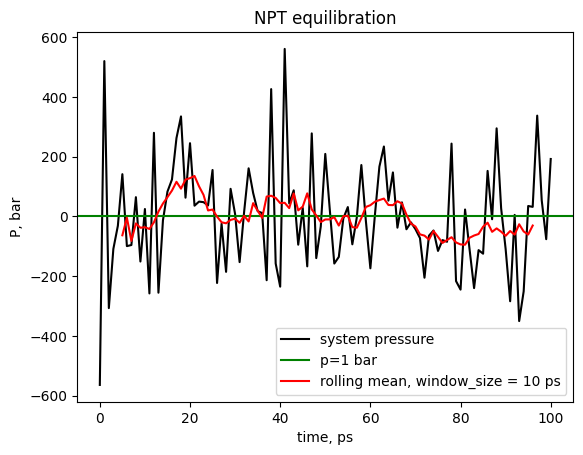

In [4]:
df = pd.read_csv('DATA/pressure.xvg', header=None, names=['time', 'pressure'], sep='\s+', skiprows = 24)
display(df)

plt.plot(df.time, df.pressure, color = 'k', label = 'system pressure')
plt.axhline(1, color = 'green', label = 'p=1 bar')

window_size = 10
p_mean = df.pressure.rolling(window = window_size, center = True).mean()
plt.plot(df.time, p_mean, color = 'r', label = 'rolling mean, window_size = ' + str(window_size) + ' ps')

plt.xlabel('time, ps')
plt.ylabel('P, bar')
plt.title('NPT equilibration')
plt.legend()

print('Pressure mean:\t', df.pressure.mean())
print('Pressure std:\t', df.pressure.std())
plt.show()

Среднее значение давления $-3 \pm 183$ бар. Целевое давление попадает в этот интервал. Большие колебания давления не страшны, т.к. давление — это величина, которая сильно колеблется в ходе моделирования методом МД. 

#### График плотности

Выбираем `25  Density`

```bash
gmx energy -f npt.edr -o density.xvg
```

,time,density
0,0.0,994.001587
1,1.0,1049.943970
2,2.0,1022.651489
3,3.0,1040.421875
4,4.0,1034.893555
...,...,...
96,96.0,1033.202393
97,97.0,1037.338867
98,98.0,1040.465576
99,99.0,1034.293579


Density mean:	 1035.558953920792
Density std:	 6.20918397695287


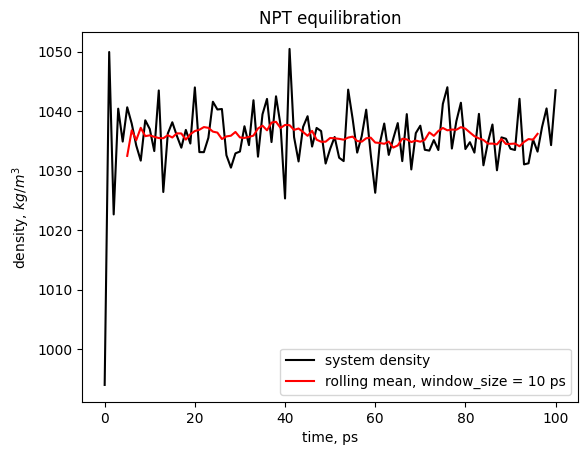

In [5]:
df = pd.read_csv('DATA/density.xvg', header=None, names=['time', 'density'], sep='\s+', skiprows = 24)
display(df)

plt.plot(df.time, df.density, color = 'k', label = 'system density')

window_size = 10
p_mean = df.density.rolling(window = window_size, center = True).mean()
plt.plot(df.time, p_mean, color = 'r', label = 'rolling mean, window_size = ' + str(window_size) + ' ps')

plt.xlabel('time, ps')
plt.ylabel('density, $kg/m^3$')
plt.title('NPT equilibration')
plt.legend()

print('Density mean:\t', df.density.mean())
print('Density std:\t', df.density.std())
plt.show()

Среднее значение близко к экспериментальному значению 1000 $кг/м^3$ и ожидаемой плотности модели TIP3P 1001 $кг/м^3$.

Плотность достаточно стабильна по времени. Значит, система уравновешена в отношении давления и плотности.

## 3.9. Молекулярная динамика (MD)

В данном разделе запускается молекулярная динамика собранной системы. 

Время моделирования 1 нс

Файл `md.mdp`

```plain
; Run parameters
integrator              = md        ; leap-frog integrator
nsteps                  = 500000    ; 2 * 500000 = 1000 ps (1 ns)
dt                      = 0.002     ; 2 fs
; Output control
nstxout                 = 0         ; suppress bulky .trr file by specifying 
nstvout                 = 0         ; 0 for output frequency of nstxout,
nstfout                 = 0         ; nstvout, and nstfout
nstenergy               = 5000      ; save energies every 10.0 ps
nstlog                  = 5000      ; update log file every 10.0 ps
nstxout-compressed      = 5000      ; save compressed coordinates every 10.0 ps
compressed-x-grps       = System    ; save the whole system
; Bond parameters
continuation            = yes       ; Restarting after NPT 
constraint_algorithm    = lincs     ; holonomic constraints 
constraints             = h-bonds   ; bonds involving H are constrained
lincs_iter              = 1         ; accuracy of LINCS
lincs_order             = 4         ; also related to accuracy
; Neighborsearching
cutoff-scheme           = Verlet    ; Buffered neighbor searching
ns_type                 = grid      ; search neighboring grid cells
nstlist                 = 10        ; 20 fs, largely irrelevant with Verlet scheme
rcoulomb                = 1.0       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.0       ; short-range van der Waals cutoff (in nm)
; Electrostatics
coulombtype             = PME       ; Particle Mesh Ewald for long-range electrostatics
pme_order               = 4         ; cubic interpolation
fourierspacing          = 0.16      ; grid spacing for FFT
; Temperature coupling is on
tcoupl                  = V-rescale             ; modified Berendsen thermostat
tc-grps                 = Protein Non-Protein   ; two coupling groups - more accurate
tau_t                   = 0.1     0.1           ; time constant, in ps
ref_t                   = 300     300           ; reference temperature, one for each group, in K
; Pressure coupling is on
pcoupl                  = Parrinello-Rahman     ; Pressure coupling on in NPT
pcoupltype              = isotropic             ; uniform scaling of box vectors
tau_p                   = 2.0                   ; time constant, in ps
ref_p                   = 1.0                   ; reference pressure, in bar
compressibility         = 4.5e-5                ; isothermal compressibility of water, bar^-1
; Periodic boundary conditions
pbc                     = xyz       ; 3-D PBC
; Dispersion correction
DispCorr                = EnerPres  ; account for cut-off vdW scheme
; Velocity generation
gen_vel                 = no        ; Velocity generation is off 
```

```bash
gmx grompp -f mdp/md.mdp -c npt.gro -t npt.cpt -p topol.top -o md.tpr
nohup gmx mdrun -v -deffnm md -gpu_id 0 -nt 10 -pin on -pinoffset 0 -pinstride 1 > md.job &

```

## 3.10. Анализ МД-траектории


Для постобработки полученной траектории используется `gmx trjconv`. Сначала с его помощью нужно учесть диффузию белка через границу элементарной ячейки. Для этого необходимо запустить команду ниже и выбрать `1 Protein` в качестве группы центрирования

```bash
gmx trjconv -s md.tpr -f md.xtc -o md_center.xtc -pbc mol -center
```

### 3.10.1. График потенциальной энергии системы от времени

Потенциальную энергию системы можно получить с помощью `gmx energy`, выбрав `12 Potential`

```bash
gmx energy -f md.edr -o Epot.xvg
```

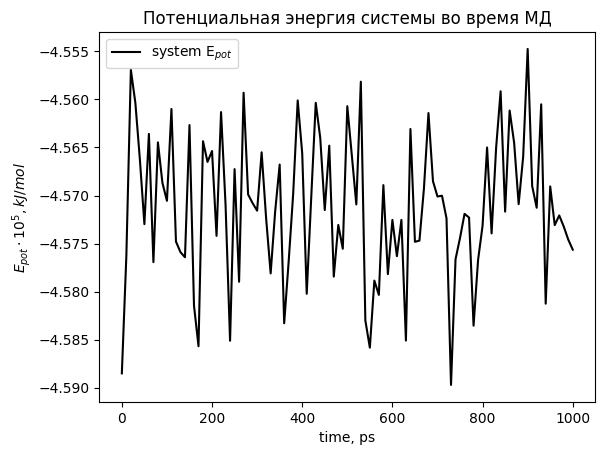

In [6]:
df = pd.read_csv('DATA/Epot.xvg', header=None, names=['time', 'Epot'], sep='\s+', skiprows = 24)
plt.plot(df.time, df.Epot/1e5, color = 'k', label = 'system E$_{pot}$')
plt.xlabel('time, ps')
plt.ylabel('$E_{pot} \cdot 10^5, kJ/mol$')
plt.title('Потенциальная энергия системы во время МД')
plt.legend()
plt.show()

### 3.10.2. Стабильность структуры белка

Стабильность белка можно оценить с помощью функции RMSD, которая рассчитывает среднеквадратичное отклонение атомов белка от его изначальной кристаллической структуры. Данная функция запускается с помощью `gmx rms` с выбором `Backbone`

```bash
gmx rms -s md.tpr -f md_center.xtc -o rmsd.xvg
```

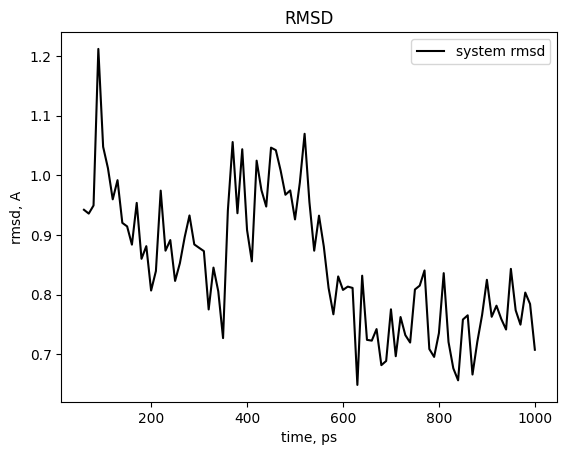

In [7]:
df = pd.read_csv('DATA/rmsd.xvg', header=None, names=['time', 'rmsd'], sep='\s+', skiprows = 24)
plt.plot(df.time, df.rmsd*10, color = 'k', label = 'system rmsd')
plt.xlabel('time, ps')
plt.ylabel('rmsd, A')
plt.title('RMSD')
plt.legend()
plt.show()

Уровень среднеквадратичного отклонения составил ~1 A, поэтому можно сказать, что структура была достаточно стабильна. 

> Туториалы: 
> 
> * http://www.mdtutorials.com/gmx/lysozyme/index.html
> * https://cbp-unitn.gitlab.io/QCB/tutorial2_gromacs.html


## 3.11. Бонусы: библиотеки для анализа МД-траекторий в Python

### 3.11.1. NGLView - быстрый просмотр структур/траекторий

> * https://github.com/nglviewer/nglview
> * https://habr.com/ru/articles/691542/
> * `Materials/nglview.pdf`

In [1]:
import nglview as ng

view = ng.show_structure_file("DATA/md.gro")
view

NGLWidget()

### 3.11.2. Библиотека MDAnalysis

> * https://www.mdanalysis.org/
> * https://proceedings.scipy.org/articles/Majora-629e541a-00e
> * https://www.researchgate.net/publication/328774554_MDAnalysis_A_Python_Package_for_the_Rapid_Analysis_of_Molecular_Dynamics_Simulations/figures

<img src="IMAGES/Example-for-how-to-calculate-the-root-mean-square-fluctuation-RMSF-for-each-residue-in_W640.jpg" alt="drawing" style="width:600px"/> 

# 4. Задание

Для своего проектного белка поставить расчет МД в воде. 
* Построить графики вдоль МД-траектории:
    * EM: потенциальной энергии системы
    * NVT: температуры системы
    * NPT: давления и плотности системы
    * MD: потенциальной энергии и RMSD белка
* Прислать: 
  * Визуализацию системы - md.gro (Pymol)
  * Все вышеперечисленные графики
  * Ваши выводы

**Дедлайн: 04.12.2025**